In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report,
                             roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import json

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Cell 2 — Load Data and Retrain XGBoost
df = pd.read_csv('/kaggle/input/datasets/fabdelja/autism-screening-for-toddlers/Toddler Autism dataset July 2018.csv')

df = df.drop(columns=['Case_No', 'Qchat-10-Score', 'Who completed the test'])

df['Sex'] = (df['Sex'] == 'm').astype(int)
df['Jaundice'] = (df['Jaundice'] == 'yes').astype(int)
df['Family_mem_with_ASD'] = (df['Family_mem_with_ASD'] == 'yes').astype(int)
le = LabelEncoder()
df['Ethnicity'] = le.fit_transform(df['Ethnicity'])
df['target'] = (df['Class/ASD Traits '] == 'Yes').astype(int)
df = df.drop(columns=['Class/ASD Traits '])

X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42
)
xgb_model.fit(X_train, y_train)

print("Ready for evaluation.")

Ready for evaluation.


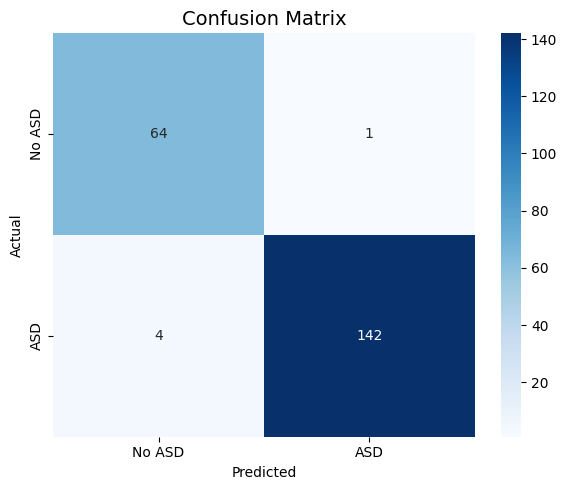

Saved: confusion_matrix.png


In [3]:
# Cell 3 — Confusion Matrix
preds = xgb_model.predict(X_test)

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No ASD', 'ASD'],
            yticklabels=['No ASD', 'ASD'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

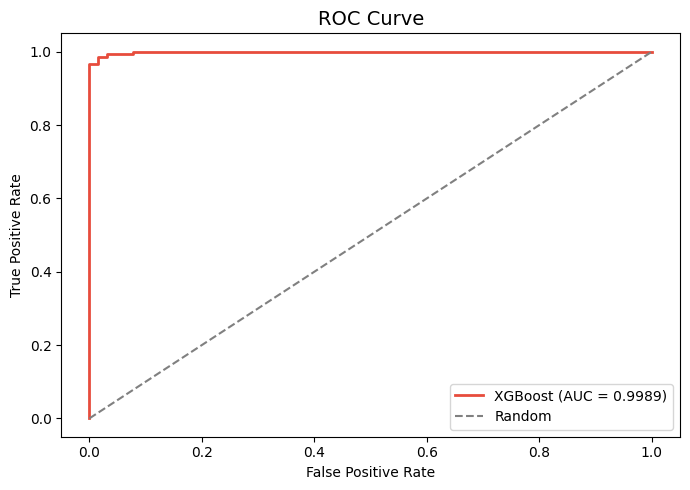

Saved: roc_curve.png


In [4]:
# Cell 4 — ROC Curve
fpr, tpr, _ = roc_curve(y_test, xgb_model.predict_proba(X_test)[:,1])
auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'XGBoost (AUC = {auc:.4f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curve.png")

In [5]:
# Cell 5a — Cross Validation (for results JSON)
from sklearn.model_selection import cross_val_score
xgb_cv = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"CV Mean: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")

CV Mean: 0.9561 ± 0.0088


In [6]:
# Cell 5 — Save Final Results
acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds)
auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])
cm = confusion_matrix(y_test, preds)

results = {
    "module": "Module 2 - ASD Behavioral Screening",
    "model": "XGBoost",
    "dataset": "Q-CHAT-10 Toddler ASD Screening (Thabtah, 2018)",
    "samples": len(df),
    "test_size": len(X_test),
    "metrics": {
        "accuracy": round(acc, 4),
        "f1_score": round(f1, 4),
        "roc_auc": round(auc, 4),
        "cv_mean": round(float(xgb_cv.mean()), 4),
        "cv_std": round(float(xgb_cv.std()), 4)
    },
    "confusion_matrix": {
        "true_negative": int(cm[0][0]),
        "false_positive": int(cm[0][1]),
        "false_negative": int(cm[1][0]),
        "true_positive": int(cm[1][1])
    },
    "top_features": ["A9", "A7", "A6", "A5", "A2"],
    "explainability": "SHAP TreeExplainer",
    "language_support": "Uzbek (Q-CHAT-10 question mapping)"
}

with open('module2_results_final.json', 'w') as f:
    json.dump(results, f, indent=4)

print("Saved: module2_results_final.json")
print("\nFinal Results:")
for k, v in results['metrics'].items():
    print(f"  {k}: {v}")

Saved: module2_results_final.json

Final Results:
  accuracy: 0.9763
  f1_score: 0.9827
  roc_auc: 0.9989
  cv_mean: 0.9561
  cv_std: 0.0088
